# 03 · Rule layer

Four typologies, each implemented as its own function in `src/rules.py` so it
can be measured on its own in notebook 05. That separation is the whole point:
a rule's own recall tells you nothing about whether it earns its alert volume.

No rule looks at the transaction ID or at the labels.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "axes.edgecolor": "#e3e2dc", "grid.color": "#e3e2dc",
                     "axes.titleweight": "bold", "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"

In [2]:
import rules
df = pd.read_csv(config.CLEAN_TRANSACTIONS, parse_dates=["timestamp"])
print(f"{len(df):,} clean transactions")

60,059 clean transactions


## Rule 1 · Structuring

Splitting one reportable sum into several payments that each sit just under the
threshold. Calibration: the band is 70-100% of GBP 10,000, and a cluster is 3+
payments inside 7 days.

Checked on **both** sides, because of the funnelling finding in notebook 01.

In [3]:
a = df.amount
for lo, hi, label in [(7000, 10000, "70-100% of threshold"),
                      (9000, 10000, "90-100% of threshold"),
                      (10000, 1e9, "at or above threshold")]:
    print(f"{label:24s}: {int(((a >= lo) & (a < hi)).sum()):>5} transactions")

70-100% of threshold    :   142 transactions
90-100% of threshold    :   109 transactions
at or above threshold   :    73 transactions


In [4]:
structuring = rules.rule_structuring(df)
print(f"alerts: {structuring.sum()}")
df[structuring].head(6)[["transaction_id", "timestamp", "sender_account",
                         "receiver_account", "amount"]]

alerts: 100


,transaction_id,timestamp,sender_account,receiver_account,amount
3892,TXNS01110,2025-01-24 11:07:52,ACC102503,ACC101913,9794.39
3893,TXNS01100,2025-01-24 11:07:52,ACC100844,ACC101913,9091.62
4023,TXNS01121,2025-01-25 05:07:52,ACC102923,ACC101913,9765.11
4106,TXNS01122,2025-01-25 17:07:52,ACC102923,ACC101913,9063.58
4113,TXNS01112,2025-01-25 18:07:52,ACC102503,ACC101913,9033.15
4157,TXNS01111,2025-01-26 01:07:52,ACC102503,ACC101913,9141.26


Multiple senders, one beneficiary, all just under the threshold, days apart.
The funnel the profiling predicted.

## Rule 2 · Rapid fund movement

A pass-through account holds funds briefly. For each credit of GBP 1,000+, the
debits from that account in the next 24 hours are summed; if they return 80% or
more of the credit, both legs are flagged.

In [5]:
rapid = rules.rule_rapid_movement(df)
print(f"alerts: {rapid.sum()}")
df[rapid].head(4)[["transaction_id", "timestamp", "sender_account",
                   "receiver_account", "amount"]]

alerts: 80


,transaction_id,timestamp,sender_account,receiver_account,amount
525,TXN0057516,2025-01-04 06:20:04,ACC100806,ACC102688,1376.65
615,TXN0013133,2025-01-04 19:22:38,ACC102688,ACC101382,1754.51
1666,TXNR0241,2025-01-11 03:04:24,ACC101117,ACC101773,41073.53
1706,TXNR0242,2025-01-11 08:04:24,ACC101773,ACC100816,42551.77


## Rule 3 · High-risk jurisdictions

The list is derived from the portfolio rather than assumed: these five countries
are the long tail of the customer book.

In [6]:
cust = pd.read_csv(config.CUSTOMERS)
counts = cust.home_country.value_counts()
print(counts.to_string())
print(f"\nhigh-risk list: {sorted(config.HIGH_RISK_COUNTRIES)}")
high_risk = rules.rule_high_risk_country(df)
print(f"alerts: {high_risk.sum():,}")

home_country
United States     344
Spain             338
France            327
United Kingdom    319
Ireland           315
Netherlands       312
Germany           306
Canada            305
Australia         302
Cyprus             34
Malta              32
Seychelles         27
Panama             21
Cayman Islands     18

high-risk list: ['Cayman Islands', 'Cyprus', 'Malta', 'Panama', 'Seychelles']
alerts: 5,178


18 to 34 accounts each, against ~300 for every mainstream country. That is the
shape a high-risk list has against a retail book.

Note the alert count already: **5,178**. Hold that thought for notebook 05.

## Rule 4 · Round amounts

Organic retail spending rarely lands on a whole pound at size. But first, check
the data actually contains such amounts.

In [7]:
print(f"exact multiples of 1000 (>= 1000): {int(((a % 1000 == 0) & (a >= 1000)).sum())}")
print(f"exact multiples of  500 (>=  500): {int(((a % 500 == 0) & (a >= 500)).sum())}")
print(f"whole pounds, no pence (>= 1000) : {int(((a == a.round(0)) & (a >= 1000)).sum())}")

exact multiples of 1000 (>= 1000): 0
exact multiples of  500 (>=  500): 0
whole pounds, no pence (>= 1000) : 49


**Zero exact multiples of 1,000.** The generator produced continuous amounts, so
the textbook version of this rule would never fire. Calibrating it to whole
pounds at GBP 1,000+ gives it something to find. Whether that is worth its
alerts is measured in notebook 05.

In [8]:
round_amt = rules.rule_round_amount(df)
print(f"alerts: {round_amt.sum()}")

alerts: 49


## All four together

In [9]:
fired = rules.apply_all(df)
summary = pd.DataFrame({
    "alerts": [int(fired[r].sum()) for r in rules.RULES],
    "% of book": [f"{fired[r].mean():.2%}" for r in rules.RULES],
}, index=list(rules.RULES))
print(summary.to_string())
print(f"\nANY RULE: {int(fired.rule_alert.sum()):,} alerts ({fired.rule_alert.mean():.2%} of the book)")

                   alerts % of book
structuring           100     0.17%
rapid_movement         80     0.13%
high_risk_country    5178     8.62%
round_amount           49     0.08%

ANY RULE: 5,384 alerts (8.96% of the book)


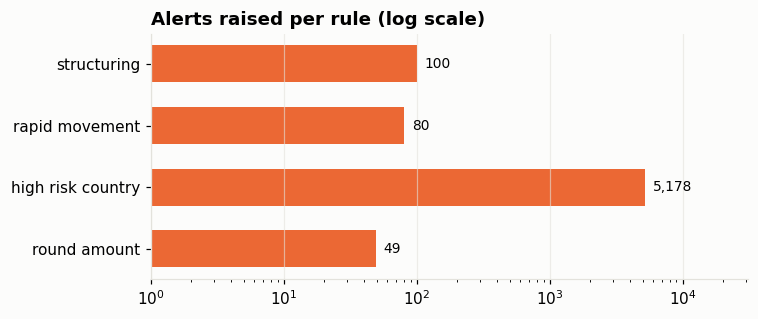

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
vals = [int(fired[r].sum()) for r in rules.RULES]
ax.barh([r.replace("_", " ") for r in rules.RULES], vals, color=S2, height=.6)
ax.set_xscale("log"); ax.invert_yaxis(); ax.grid(axis="x", alpha=.6)
for i, v in enumerate(vals):
    ax.text(v * 1.15, i, f"{v:,}", va="center", fontsize=9)
ax.set_xlim(1, max(vals) * 6); ax.set_title("Alerts raised per rule (log scale)", loc="left")
plt.tight_layout(); plt.show()

One rule raises 96% of the alerts. Whether it deserves them is the question
notebook 05 answers, and the answer drives the whole project.